# Lab 5: Support Vector Machines (SVM) with Kernel Tricks
### CS2227: Artificial Intelligence and Machine Learning

---

## Objective
In this lab we implement **Support Vector Machines (SVM)** and explore how different **Kernel Functions**
allow SVM to handle both linear and non-linear classification boundaries.

We progressively test three kernels — **Linear**, **Polynomial**, and **RBF** — on concentric circle
data that is inherently non-linearly separable.

---

## Mathematical Intuition

### 1. The Margin Objective
SVM finds the hyperplane that **maximizes the margin** between classes:

$$ \underset{w}{\arg\max} \frac{2}{||w||} \quad \text{subject to} \quad y_i(w^T x_i + b) \geq 1 $$

### 2. The Kernel Trick
When data is **non-linearly separable**, a **Kernel Function** implicitly maps features into a
higher-dimensional space where a linear hyperplane *can* separate them — without computing
the actual transformation (saving enormous computation).

Here are some common kernel functions:

*   **Linear Kernel:** $K(x, x') = x^T x'$ (for linearly separable data)
*   **Polynomial Kernel:** $K(x, x') = (\gamma x^T x' + r)^d$ (for moderate non-linearity)
*   **RBF Kernel:** $K(x, x') = \exp(-\gamma \|x - x'\|^2)$ (for complex/circular boundaries)

> **Critical Rule:** SVM computes **Euclidean distances** $\|x - x'\|^2$ between points.
> Features with larger scales will dominate this calculation. Always apply `StandardScaler` before fitting any SVM.

---
## Step 1: Imports, Helper Function, and Data Preparation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


def plot_decision_boundary(clf, X, y, title):
    plt.figure(figsize=(6, 5))
    ax = plt.gca()

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=25)
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())
    plt.tight_layout()
    plt.show()

In [2]:
X, y = make_circles(
    n_samples=300,
    factor=0.3,
    noise=0.1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set size : {X_train_scaled.shape}")
print(f"Test set size     : {X_test_scaled.shape}")
print(f"Feature mean after scaling (train): {X_train_scaled.mean(axis=0).round(4)}  ← should be ~0")
print(f"Feature std  after scaling (train): {X_train_scaled.std(axis=0).round(4)}   ← should be ~1")

Training set size : (210, 2)
Test set size     : (90, 2)
Feature mean after scaling (train): [-0. -0.]  ← should be ~0
Feature std  after scaling (train): [1. 1.]   ← should be ~1


---
## Step 2: Linear Kernel

The linear kernel tries to separate classes with a **straight hyperplane**.
Because our data forms concentric circles, a line **cannot** capture the true boundary.
We expect poor performance here — this is intentional and illustrative.

Linear Kernel Accuracy: 0.42
Observation: A linear boundary cannot capture circular class separation.


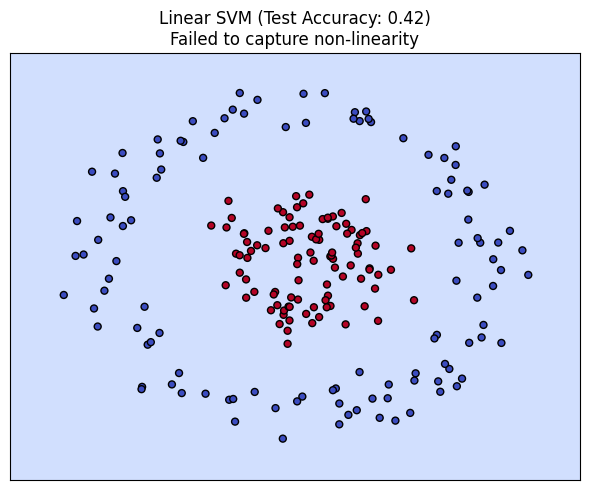

In [4]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

linear_preds = svm_linear.predict(X_test_scaled)
linear_acc   = accuracy_score(y_test, linear_preds)

print(f"Linear Kernel Accuracy: {linear_acc:.2f}")
print("Observation: A linear boundary cannot capture circular class separation.")

plot_decision_boundary(
    svm_linear,
    X_train_scaled,
    y_train,
    f"Linear SVM (Test Accuracy: {linear_acc:.2f})\nFailed to capture non-linearity"
)

---
## Step 3: Polynomial Kernel

The polynomial kernel maps features into a higher-dimensional polynomial space:
$$K(x, x') = (\gamma x^T x' + r)^d$$

With `degree=3`, the boundary is allowed to curve. This should do better than the
linear kernel but may still struggle with a perfect circle.

Polynomial Kernel Accuracy: 0.42
Observation: Polynomial kernel captures some curvature but may not perfectly isolate the inner circle.


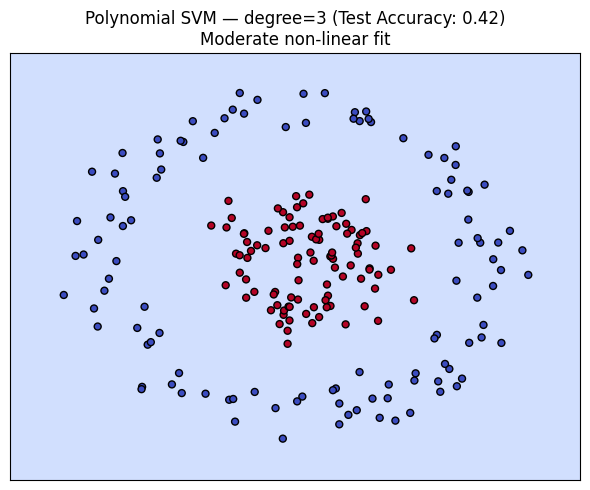

In [5]:
svm_poly = SVC(kernel='poly', degree=3, C=1.0)
svm_poly.fit(X_train_scaled, y_train)

poly_preds = svm_poly.predict(X_test_scaled)
poly_acc   = accuracy_score(y_test, poly_preds)

print(f"Polynomial Kernel Accuracy: {poly_acc:.2f}")
print("Observation: Polynomial kernel captures some curvature but may not perfectly isolate the inner circle.")

plot_decision_boundary(
    svm_poly,
    X_train_scaled,
    y_train,
    f"Polynomial SVM — degree=3 (Test Accuracy: {poly_acc:.2f})\nModerate non-linear fit"
)

---
## Step 4: RBF Kernel (Radial Basis Function)

The RBF kernel effectively maps data into **infinite-dimensional** space:
$$K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)$$

This allows it to model **any** smooth decision boundary — including perfect circles.
- `gamma='scale'` → $\gamma = \frac{1}{n\_features \times \text{Var}(X)}$
- `C=1.0` → standard regularization

This is the **expected best performer** on concentric circle data.

RBF Kernel Accuracy: 1.00
Observation: RBF perfectly captures the circular decision boundary.


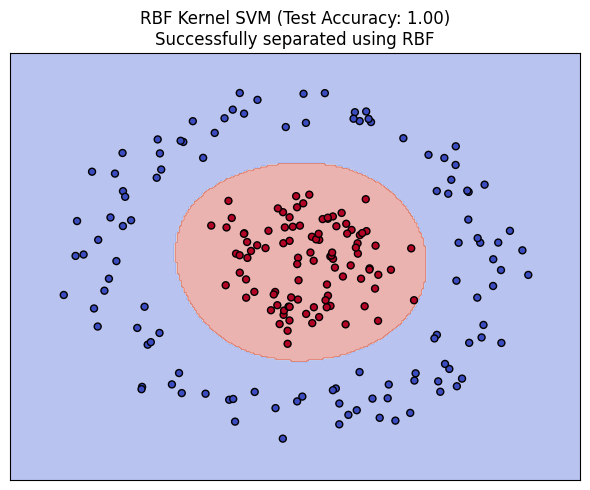

In [6]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)

rbf_preds = svm_rbf.predict(X_test_scaled)
rbf_acc   = accuracy_score(y_test, rbf_preds)

print(f"RBF Kernel Accuracy: {rbf_acc:.2f}")
print("Observation: RBF perfectly captures the circular decision boundary.")

plot_decision_boundary(
    svm_rbf,
    X_train_scaled,
    y_train,
    f"RBF Kernel SVM (Test Accuracy: {rbf_acc:.2f})\nSuccessfully separated using RBF"
)

---
## Step 5: Kernel Comparison Summary

In [8]:
print("=" * 45)
print(f"{'Kernel':<15} {'Test Accuracy':>13} {'Result'}")
print("=" * 45)
print(f"{'Linear':<15} {linear_acc:>13.2f}  {'Failed (linear boundary)'}")
print(f"{'Polynomial':<15} {poly_acc:>13.2f}  {'Partial (curved boundary)'}")
print(f"{'RBF':<15} {rbf_acc:>13.2f}  {'Excellent (circular boundary)'}")
print("=" * 45)

Kernel          Test Accuracy Result
Linear                   0.42  Failed (linear boundary)
Polynomial               0.42  Partial (curved boundary)
RBF                      1.00  Excellent (circular boundary)


---
## Summary

| Kernel | Key Idea | Performance on Circles |
|--------|----------|------------------------|
| **Linear** | Straight hyperplane | Poor — can't curve |
| **Polynomial** | Projects into polynomial space | Moderate — partial curvature |
| **RBF** | Maps to infinite-dimensional Gaussian space | Excellent — captures circular boundary |

**Key Takeaway:** The choice of kernel determines which shapes of decision boundary the SVM can draw.
For radially structured data (circles), RBF is the natural best choice.